#**CLUSTERING ANALYSIS**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import zscore

In [ ]:
df = pd.read_excel("EastWestAirlines.xlsx",sheet_name='data')

In [ ]:
 # First 5 rows
print(df.head())

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  


In [ ]:
# Column info and data types
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None


In [ ]:
# Rows and columns
print(df.shape)

(3999, 12)


In [ ]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


##Data Preprocessing

In [ ]:
# Handle missing values
df= df.dropna()

In [46]:
# Remove outliers (using z-score)
df_z = df[(np.abs(zscore(df.select_dtypes(include=[np.number]))) < 3).all(axis=1)]

In [ ]:
# Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.select_dtypes(include=[np.number]))

##Exploratory Data Analysis (EDA)

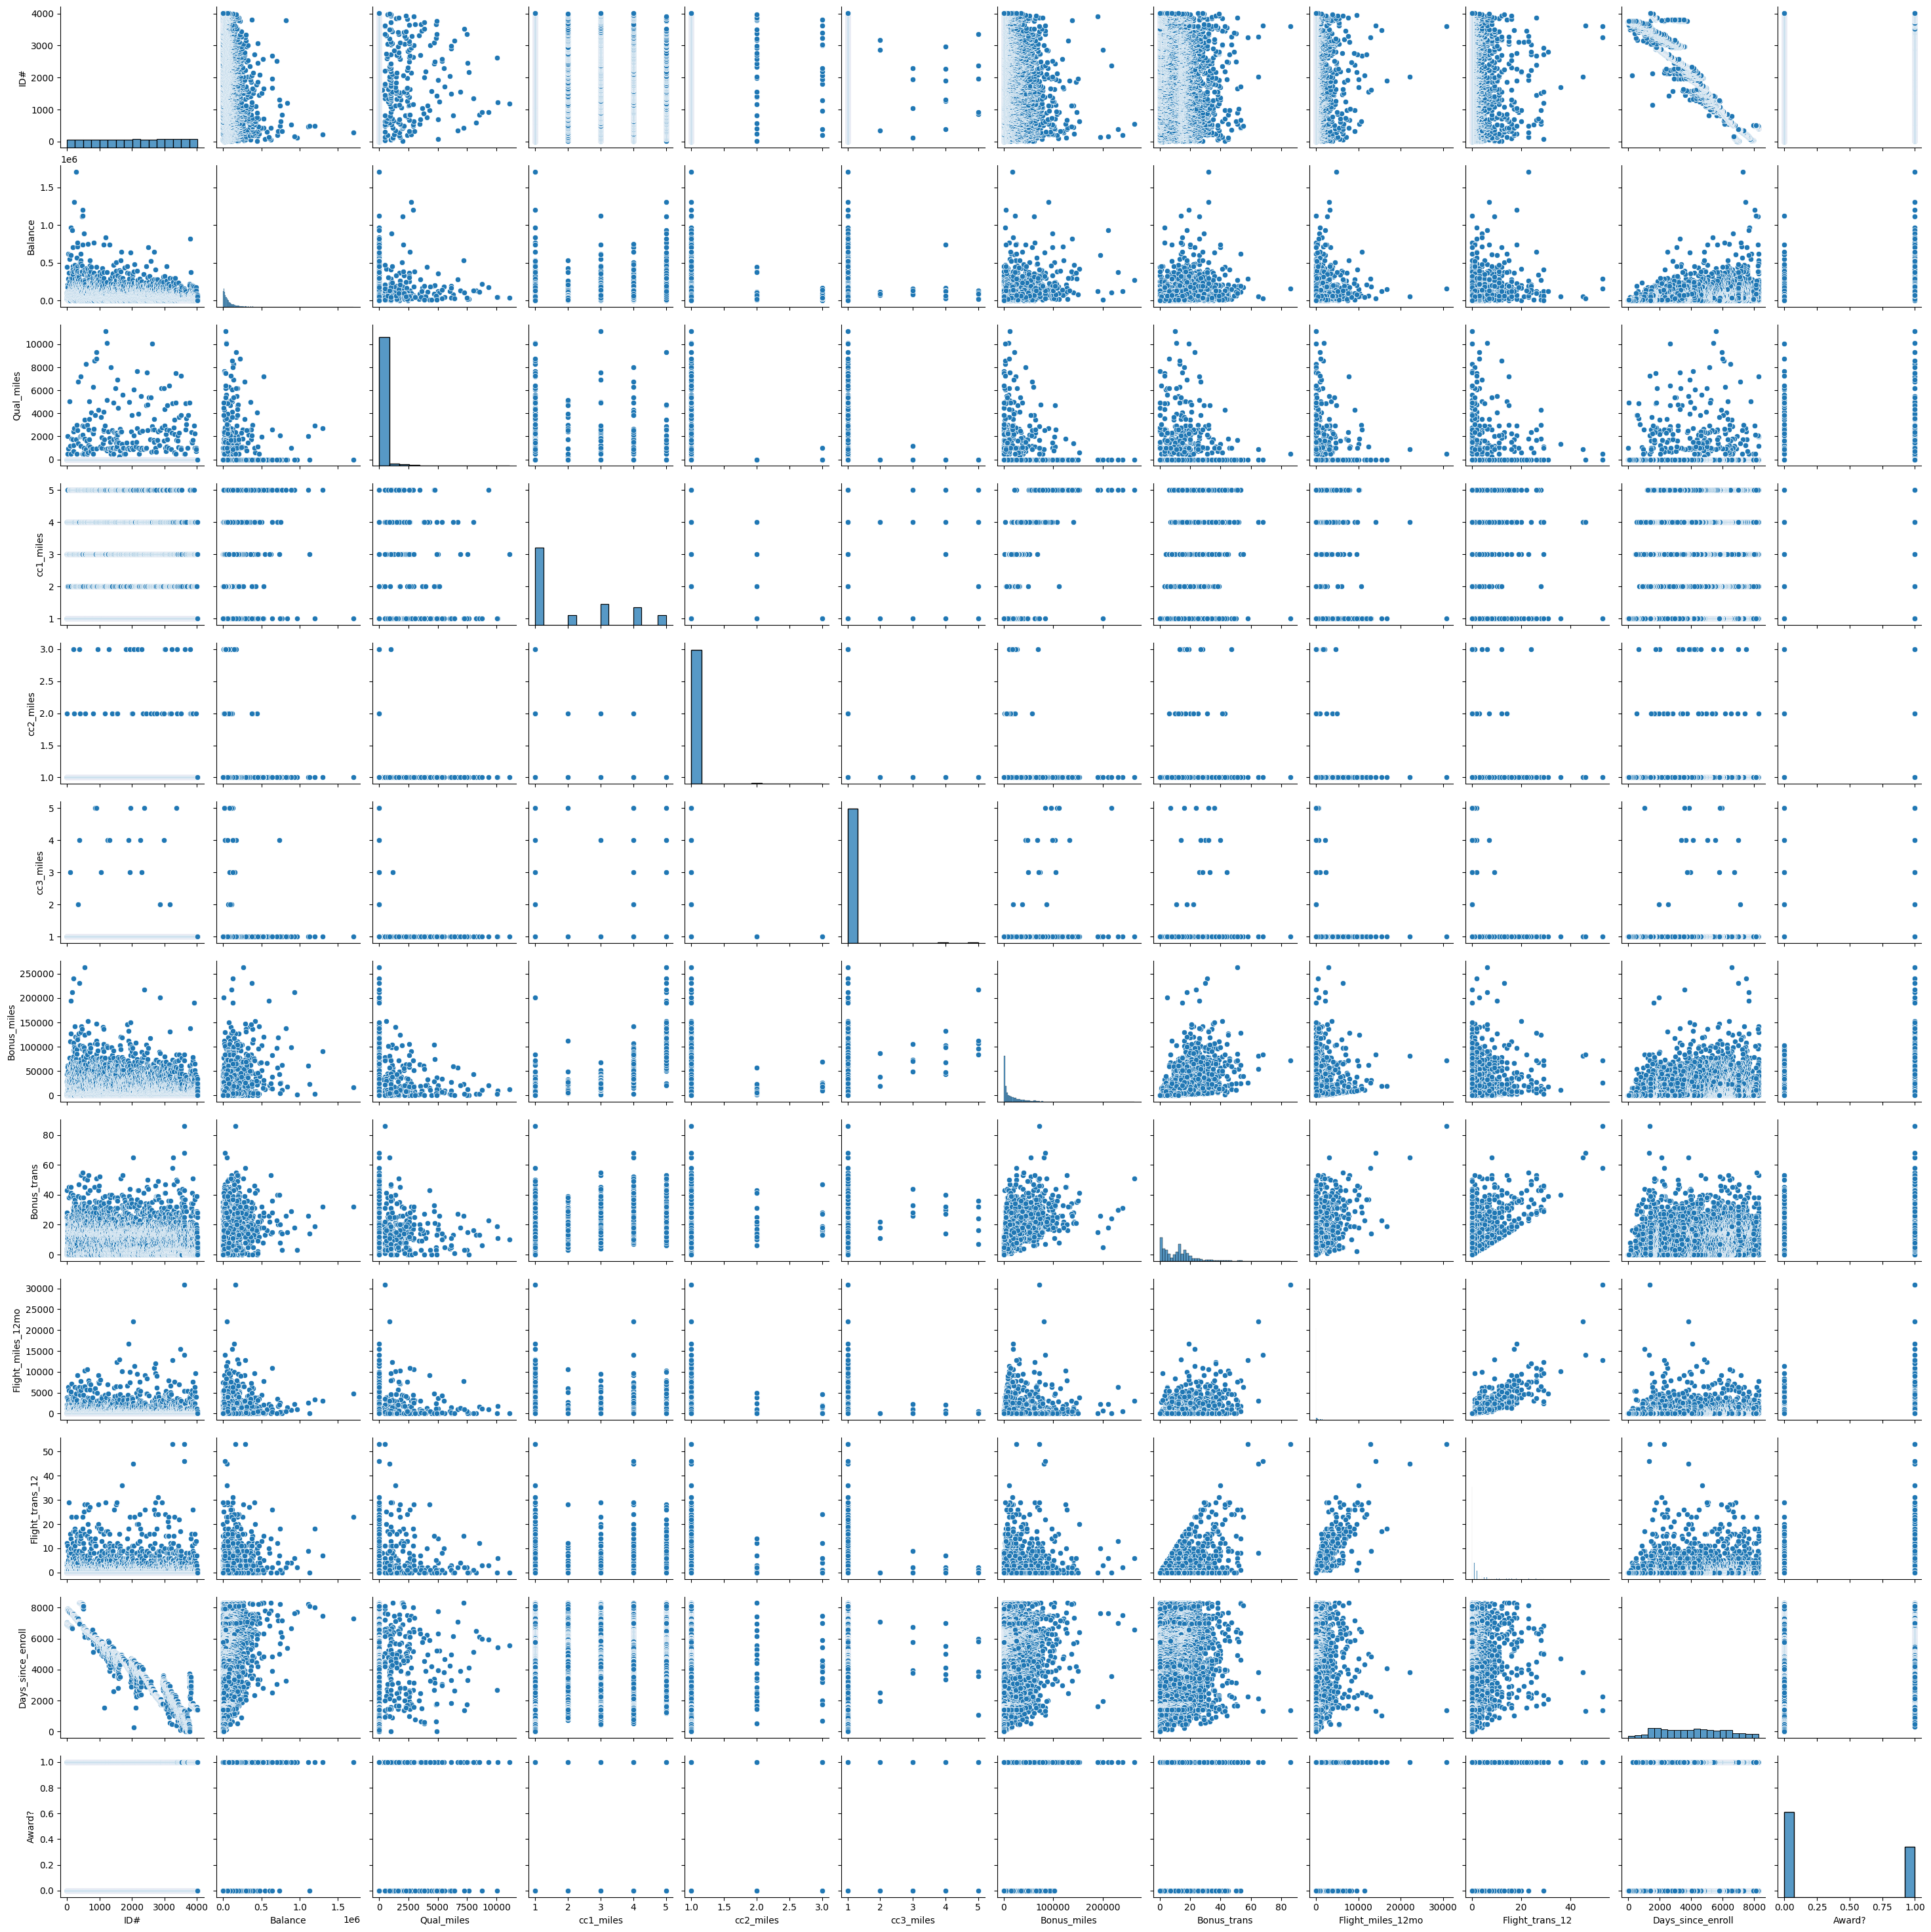

In [ ]:
# Pairplot for numerical features
sns.pairplot(df.select_dtypes(include=[np.number]))
plt.show()

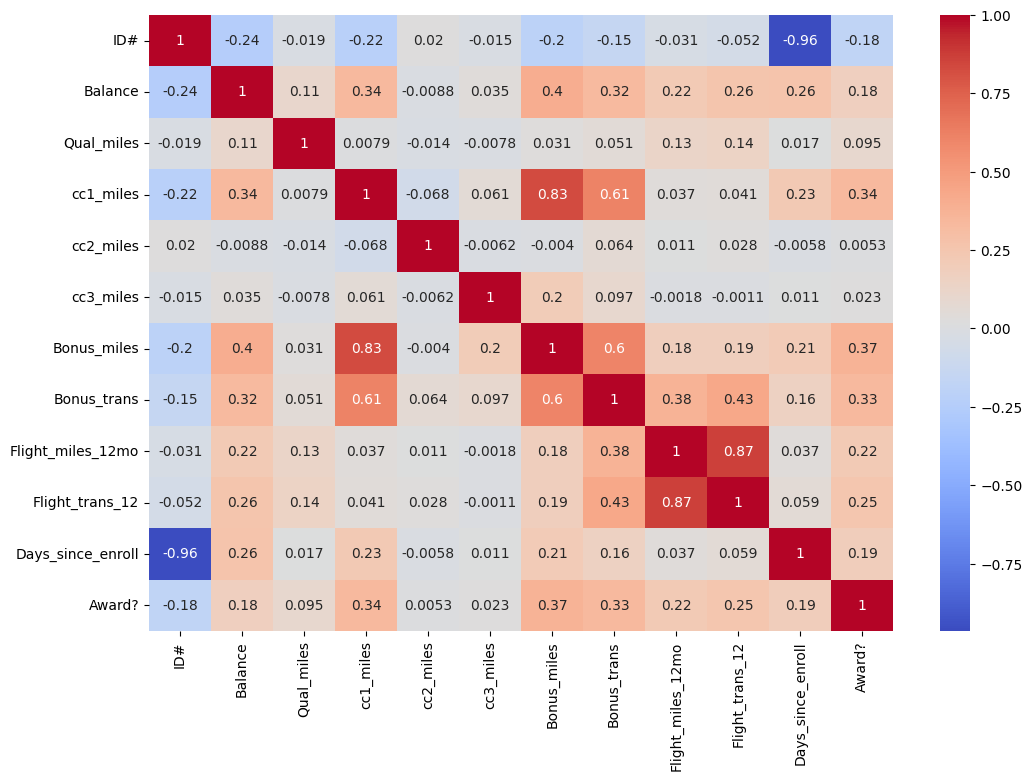

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

##K-Means Clustering

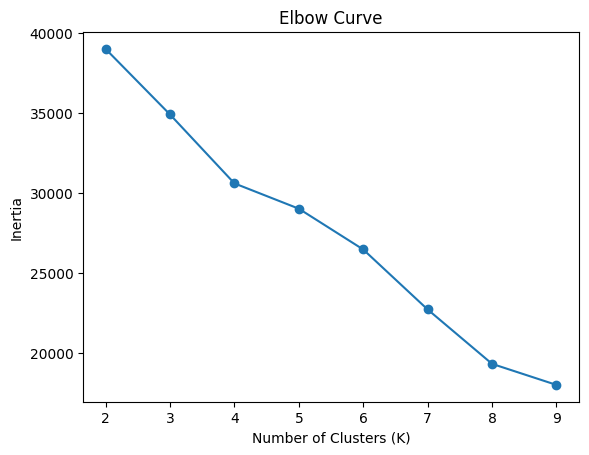

In [42]:
# Elbow Method
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.show()

In [43]:
# Fit KMeans with chosen K (ex: K=3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

In [44]:
# Evaluate
print("Silhouette Score (KMeans):", silhouette_score(scaled_data, kmeans_labels))

Silhouette Score (KMeans): 0.201891717665419


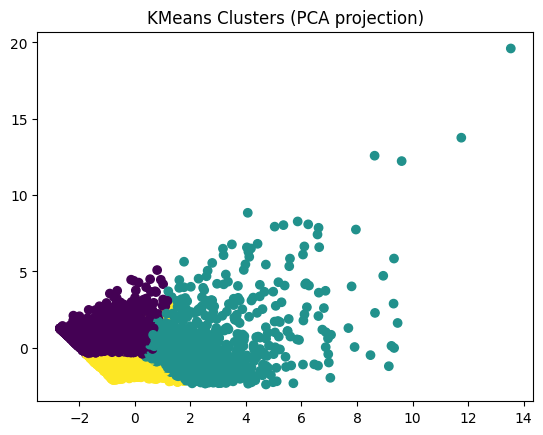

In [48]:
# Visualize clusters (PCA projection)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)
plt.scatter(reduced_data[:,0], reduced_data[:,1], c=kmeans_labels, cmap="viridis")
plt.title("KMeans Clusters (PCA projection)")
plt.show()

##DBSCAN Clustering

In [49]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

In [55]:
# Evaluate
mask = dbscan_labels != -1
print("Silhouette Score (DBSCAN):", silhouette_score(scaled_data[mask], dbscan_labels[mask]))

Silhouette Score (DBSCAN): -0.10765271486979784


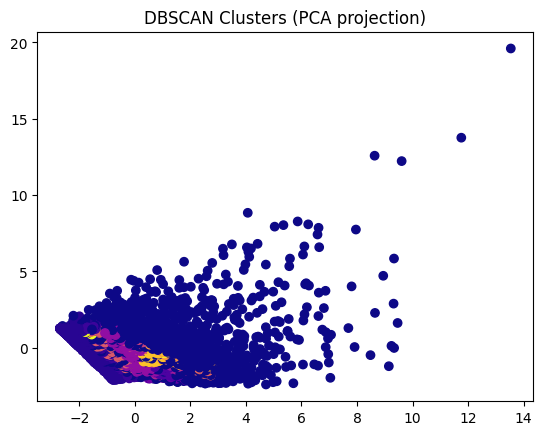

In [56]:
# Visualize DBSCAN clusters
plt.scatter(reduced_data[:,0], reduced_data[:,1], c=dbscan_labels, cmap="plasma")
plt.title("DBSCAN Clusters (PCA projection)")
plt.show()

##Cluster Analysis

In [58]:
df["KMeans_Cluster"] = kmeans_labels
df["DBSCAN_Cluster"] = dbscan_labels

In [59]:
print("Cluster Means (KMeans):")
print(df.groupby("KMeans_Cluster").mean())

Cluster Means (KMeans):
                        ID#        Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                 
0               3111.388308   40980.913231  105.005538   1.444308   1.016615   
1               1533.872934  150218.949380  297.365702   3.833678   1.007231   
2               1078.568990   58553.187767   83.805121   1.549075   1.017070   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                1.001846   6917.616000     8.138462         237.179692   
1                1.046488  48249.512397    21.637397        1197.568182   
2                1.000711   7550.203414     8.695590         209.886202   

                Flight_trans_12  Days_since_enroll    Award?  DBSCAN_Cluster  
KMeans_Cluster                                                                
0                      0.691077        21

In [60]:
print("Cluster Means (DBSCAN):")
print(df.groupby("DBSCAN_Cluster").mean())

Cluster Means (DBSCAN):
                        ID#        Balance  Qual_miles  cc1_miles  cc2_miles  \
DBSCAN_Cluster                                                                 
-1              1839.352347  123475.681521  342.432561   2.667855   1.034462   
 0              2358.402996   26688.362340    0.000000   1.000000   1.000000   
 1              1998.293023   26520.446512    0.000000   1.000000   1.000000   
 2               629.707317  102014.536585    0.000000   4.000000   1.000000   
 3               238.363636   48066.272727    0.000000   3.000000   1.000000   
 4               297.000000  138516.800000    0.000000   2.000000   1.000000   
 5               217.285714  123539.857143    0.000000   3.000000   1.000000   
 6              1992.518349   73472.412844    0.000000   3.000000   1.000000   
 7               703.709677   46331.419355    0.000000   4.000000   1.000000   
 8               286.857143   17605.571429    0.000000   2.000000   1.000000   
 9              

###K-Means
- Cluster 0 may represent customers with high mileage and frequent flyer points.
- Cluster 1 could be moderate users with balanced travel and loyalty scores.
- Cluster 2 might represent occasional flyers with low engagement and fewer points.


###DBSCAN
1: DBSCAN identified dense clusters of frequent flyers, separating them from sparse/noisy data.

 2: Noise points (-1 label) may correspond to outliers such as customers with unusual travel patterns.

 3: Compared to K-Means, DBSCAN is better at handling irregular shapes and detecting anomalies.


### General Insights:
- K-Means provides well-separated, balanced clusters but assumes spherical distribution.
- DBSCAN highlights anomalies and dense regions, useful for detecting special customer segments.
- Combining both methods gives a richer understanding: K-Means for segmentation, DBSCAN for anomaly detection.
